In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('synthetic_amr_data.csv')
df.head()

,age,gender,specimen,organism,antibiotic,resistant
0,52,M,urine,E. coli,Ciprofloxacin,0
1,15,F,sputum,K. pneumoniae,Ceftriaxone,1
2,72,M,urine,K. pneumoniae,Meropenem,0
3,61,F,sputum,P. aeruginosa,Ceftriaxone,1
4,21,F,sputum,S. aureus,Ceftriaxone,0


In [2]:
df.shape

(500, 6)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   age         500 non-null    int64 
 1   gender      500 non-null    object
 2   specimen    500 non-null    object
 3   organism    500 non-null    object
 4   antibiotic  500 non-null    object
 5   resistant   500 non-null    int64 
dtypes: int64(2), object(4)
memory usage: 23.6+ KB


In [4]:
df.describe()

,age,resistant
count,500.00000,500.000000
mean,44.31000,0.372000
std,26.14569,0.483822
min,1.00000,0.000000
25%,22.00000,0.000000
50%,44.50000,0.000000
75%,64.00000,1.000000
max,90.00000,1.000000


In [5]:
df['organism'].value_counts()

organism
E. coli          139
S. aureus        125
K. pneumoniae    124
P. aeruginosa    112
Name: count, dtype: int64

In [6]:
df['antibiotic'].value_counts()

antibiotic
Levofloxacin     108
Ceftriaxone      106
Ciprofloxacin    100
Amikacin         100
Meropenem         86
Name: count, dtype: int64

In [7]:
df['specimen'].value_counts()

specimen
sputum    172
blood     169
urine     159
Name: count, dtype: int64

In [8]:
df['gender'].value_counts()

gender
M    268
F    232
Name: count, dtype: int64

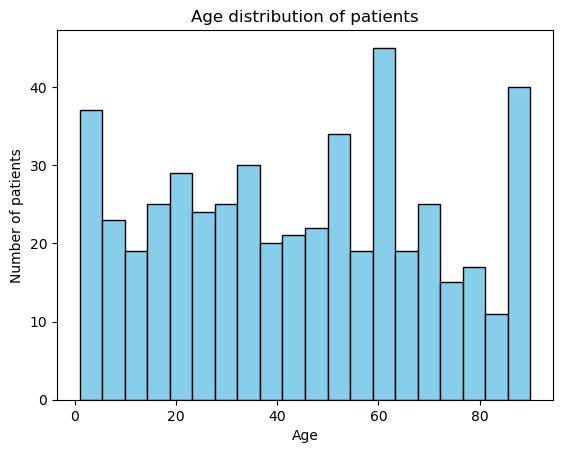

In [9]:
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Age distribution of patients')
plt.xlabel('Age')
plt.ylabel('Number of patients')
plt.show()

In [10]:
overall_rate = df['resistant'].mean() * 100
print(f"Overall resistance rate: {overall_rate:.1f}%")

Overall resistance rate: 37.2%


In [11]:
organism_rate = df.groupby('organism')['resistant'].mean() * 100
print("Resistance rate by organism (%):")
print(organism_rate)

Resistance rate by organism (%):
organism
E. coli          46.762590
K. pneumoniae    39.516129
P. aeruginosa    35.714286
S. aureus        25.600000
Name: resistant, dtype: float64


In [12]:
antibiotic_rate = df.groupby('antibiotic')['resistant'].mean() * 100
print("Resistance rate by antibiotic (%):")
print(antibiotic_rate)

Resistance rate by antibiotic (%):
antibiotic
Amikacin         19.000000
Ceftriaxone      57.547170
Ciprofloxacin    48.000000
Levofloxacin     47.222222
Meropenem         8.139535
Name: resistant, dtype: float64


In [13]:
pivot = pd.pivot_table(df, values='resistant', index='organism', columns='antibiotic', aggfunc='mean') * 100
print("Resistance rate (%) by organism and antibiotic:")
pivot

Resistance rate (%) by organism and antibiotic:


antibiotic,Amikacin,Ceftriaxone,Ciprofloxacin,Levofloxacin,Meropenem
organism,,,,,
E. coli,23.076923,60.000000,69.444444,52.000000,0.000000
K. pneumoniae,24.000000,66.666667,47.826087,48.387097,12.500000
P. aeruginosa,5.000000,60.869565,33.333333,52.173913,21.052632
S. aureus,20.689655,44.444444,21.428571,37.931034,0.000000


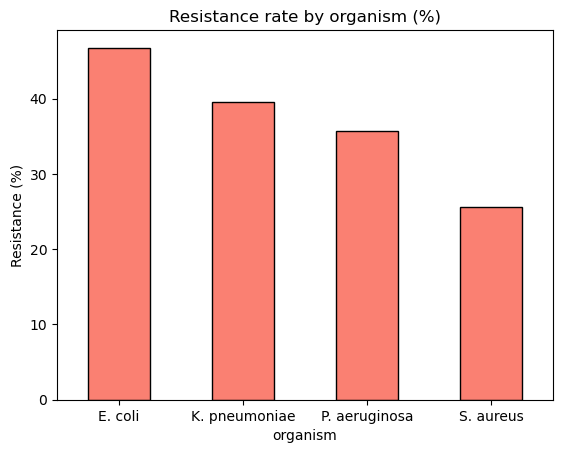

In [14]:
organism_rate.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Resistance rate by organism (%)')
plt.ylabel('Resistance (%)')
plt.xticks(rotation=0)
plt.show()

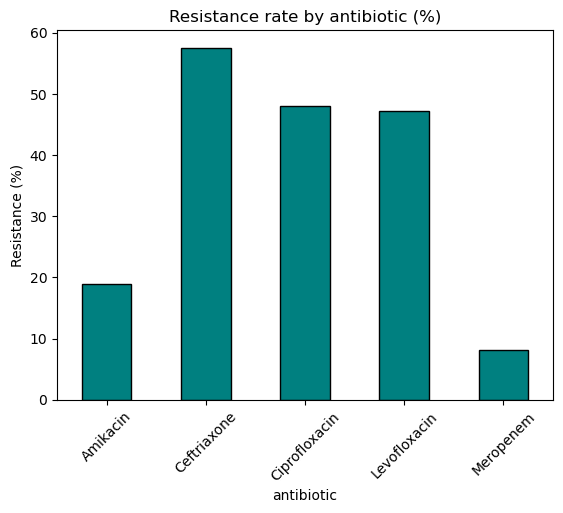

In [15]:
antibiotic_rate.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Resistance rate by antibiotic (%)')
plt.ylabel('Resistance (%)')
plt.xticks(rotation=45)
plt.show()

In [16]:
df.to_csv('antibiotic_resistance_dataset.csv', index=False)
print("Cleaned dataset saved as 'antibiotic_resistance_dataset.csv'")

Cleaned dataset saved as 'antibiotic_resistance_dataset.csv'
